# Marginalising one lens: Monte Carlo vs quadrature

hierArc marginalises each lens over the latent parameters its population distributions
describe — the internal mass sheet `lambda_mst`, the external convergence `kappa_ext`, the
stellar anisotropy and, for axisymmetric models, the intrinsic axis ratio `q_intrinsic`.
By default it does this by drawing `num_distribution_draws` samples and averaging.

That estimator is unbiased **in the likelihood**, so the sampler still targets the correct
posterior. But its variance can be large: when a lens's own kinematics constrain the latent
parameters far more tightly than the population distribution does, nearly all the weight
falls on a single draw and `log L` picks up several nats of noise. Because emcee then
behaves as a pseudo-marginal sampler, that noise shows up as poor mixing rather than as
bias.

This notebook compares the default Monte Carlo loop against the optional deterministic
quadrature (`marginalisation="quadrature"`) on a single lens:

1. how far each is from a converged reference,
2. how the two scale in cost,
3. and how much the answer moves between repeated evaluations at *identical* parameters.

The quadrature is **off by default**; nothing here changes the behaviour of an existing
run.

In [1]:
import time
import warnings

import numpy as np
import matplotlib.pyplot as plt

from hierarc.Likelihood.hierarchy_likelihood import LensLikelihood

warnings.filterwarnings("ignore")
np.random.seed(0)

## 1. A lens to work with

We build a `DdtHistKin` lens — a time-delay distance posterior plus a covariant set of
binned velocity dispersions — with a 3d kinematics-scaling grid in
(`a_ani`, `gamma_pl`, `q_intrinsic`) and an external-convergence histogram. That is the
configuration the quadrature covers.

`N_BINS` is the knob that matters most here. The more resolved kinematic bins a lens has,
the more sharply its own data constrain the latent parameters, and the worse the Monte
Carlo estimator behaves. Try 3 and then 40.

In [2]:
N_BINS = 40          # resolved kinematic bins; raise this to make the MC estimator struggle
N_GRID = (7, 5, 5)   # the (a_ani, gamma_pl, q_intrinsic) tabulation of J

axes = [
    np.linspace(-0.49, 1.0, N_GRID[0]),   # a_ani, interpolated as beta = 1 - a^2
    np.linspace(1.5, 2.5, N_GRID[1]),     # gamma_pl
    np.linspace(0.2, 1.0, N_GRID[2]),     # q_intrinsic
]

# a smooth, monotonic J tabulated on that grid, one grid per kinematic bin
b, g, q = np.meshgrid(*axes, indexing="ij")
j_shape = 1.0 + 0.55 * (b - axes[0][0]) + 0.20 * (g - 2.0) - 0.35 * (q - 0.7)
grid_list = [j_shape * (1.0 + 0.02 * np.sin(3 * i)) for i in range(N_BINS)]

j_model = np.linspace(0.95, 1.05, N_BINS)
sigma_v = 260 + 4.0 * np.sin(np.arange(N_BINS))
# a tight measurement covariance is what makes the likelihood informative
error_cov_measurement = np.diag((sigma_v * 0.02) ** 2) + 9.0
error_cov_j_sqrt = np.diag(j_model * 5e-4) + 5e-5

kappa_edges = np.linspace(-0.06, 0.18, 61)
kappa_mid = 0.5 * (kappa_edges[:-1] + kappa_edges[1:])
kappa_pdf = np.exp(-0.5 * ((kappa_mid - 0.03) / 0.035) ** 2)

kwargs_lens_setup = dict(
    z_lens=0.30,
    z_source=2.0,
    name="DEMO",
    likelihood_type="DdtHistKin",
    ddt_samples=np.random.normal(2600, 120, 20000),
    sigma_v_measurement=sigma_v,
    j_model=j_model,
    error_cov_measurement=error_cov_measurement,
    error_cov_j_sqrt=error_cov_j_sqrt,
    kin_scaling_param_list=["a_ani", "gamma_pl", "q_intrinsic"],
    j_kin_scaling_param_axes=axes,
    j_kin_scaling_grid_list=grid_list,
    anisotropy_model="const",
    anisotropy_sampling=True,
    anisotropy_distribution="GAUSSIAN",
    anisotropy_parameterization="TAN_RAD",
    q_intrinsic_sampling=True,
    q_intrinsic_distribution="GAUSSIAN",
    lambda_mst_distribution="GAUSSIAN",
    los_distribution_individual="PDF",
    kwargs_los_individual={"bin_edges": kappa_edges, "pdf_array": kappa_pdf},
    gamma_pl_index=0,
    normalized=False,
)

# the hyperparameters we evaluate at, and the distances from the cosmology
KWARGS_LENS = dict(lambda_mst=1.0, lambda_mst_sigma=0.05, gamma_pl_list=[2.0])
KWARGS_KIN = dict(a_ani=1.0, a_ani_sigma=0.10, q_intrinsic=0.70, q_intrinsic_sigma=0.08)
DDT, DD = 3100.0, 1250.0

def evaluate(lens):
    """Marginal log likelihood of the lens at the fixed hyperparameters above."""
    return lens.hyper_param_likelihood(
        DDT, DD, 0, beta_dsp=None,
        kwargs_lens=KWARGS_LENS, kwargs_kin=KWARGS_KIN,
        kwargs_source={}, kwargs_los=[],
    )

print(f"{N_BINS} kinematic bins, J tabulated on a {'x'.join(map(str, N_GRID))} grid")

40 kinematic bins, J tabulated on a 7x5x5 grid


## 2. A converged reference

The quadrature converges geometrically, so we can get a trustworthy reference simply by
refining it until it stops moving. Two independent settings agreeing to many digits is the
check that the reference is real and not a fixed point of one particular rule.

In [11]:
ref_a = LensLikelihood(
    marginalisation="quadrature",
    kwargs_marginalisation={"n_gauss": 8, "n_lambda_tot": 1024, "kappa_sub_bin": 3},
    **kwargs_lens_setup,
)
ref_b = LensLikelihood(
    marginalisation="quadrature",
    kwargs_marginalisation={"n_gauss": 9, "n_lambda_tot": 768, "kappa_sub_bin": 2},
    **kwargs_lens_setup,
)
REFERENCE = evaluate(ref_a)
check = evaluate(ref_b)
print(f"reference    log L = {REFERENCE:.9f}")
print(f"independent  log L = {check:.9f}")
print(f"difference         = {check - REFERENCE:+.2e}   <- this is the reference's own error")

reference    log L = -7994.069594313
independent  log L = -7994.069594304
difference         = +8.12e-09   <- this is the reference's own error


## 3. How each method converges

For the quadrature, `n_gauss` is the number of Gauss-Legendre nodes per panel in the
anisotropy and deprojection directions; the number of eigendecompositions per evaluation
is reported as `num_nodes`.

For the Monte Carlo loop we report the **RMS error over repeated evaluations**, since its
error is random rather than fixed: a single evaluation tells you nothing about how far off
it typically is.

In [12]:
def time_call(fn, repeats):
    fn()  # warm up
    start = time.time()
    values = [fn() for _ in range(repeats)]
    return np.array(values), (time.time() - start) / repeats

rows = []

for n_gauss in (2, 3, 4, 5, 6):
    lens = LensLikelihood(
        marginalisation="quadrature",
        kwargs_marginalisation={"n_gauss": n_gauss, "n_lambda_tot": 256},
        **kwargs_lens_setup,
    )
    values, dt = time_call(lambda: evaluate(lens), 3)
    rows.append(("quadrature", f"n_gauss={n_gauss}", lens._quadrature.num_nodes,
                 values[0], abs(values[0] - REFERENCE), dt))

for n_draws in (50, 200, 800, 3200):
    lens = LensLikelihood(num_distribution_draws=n_draws, **kwargs_lens_setup)
    repeats = max(int(40000 / n_draws), 12)
    values, dt = time_call(lambda: evaluate(lens), repeats)
    finite = values[np.isfinite(values)]
    rmse = float(np.sqrt(np.mean((finite - REFERENCE) ** 2)))
    rows.append(("monte carlo", f"{n_draws} draws", n_draws,
                 float(np.mean(finite)), rmse, dt))

print(f"{'method':<12} {'setting':<14} {'nodes':>7} {'log L':>14} {'error (nats)':>13} {'ms/eval':>9}")
print("-" * 74)
for method, setting, nodes, value, err, dt in rows:
    print(f"{method:<12} {setting:<14} {nodes:>7d} {value:>14.6f} {err:>13.2e} {1e3*dt:>9.1f}")
print()
print("for the Monte Carlo rows 'error' is the RMS over repeated evaluations, not a fixed offset")

method       setting          nodes          log L  error (nats)   ms/eval
--------------------------------------------------------------------------
quadrature   n_gauss=2           96   -7994.089176      1.96e-02      33.4
quadrature   n_gauss=3          216   -7994.067779      1.82e-03      65.1
quadrature   n_gauss=4          384   -7994.069681      8.67e-05     127.5
quadrature   n_gauss=5          600   -7994.069592      2.31e-06     171.0
quadrature   n_gauss=6          864   -7994.069595      3.07e-07     238.3
monte carlo  50 draws            50   -7994.145315      4.22e-01       4.6
monte carlo  200 draws          200   -7994.074785      1.98e-01      18.3
monte carlo  800 draws          800   -7994.072112      9.34e-02      72.4
monte carlo  3200 draws        3200   -7994.061842      5.12e-02     291.3

for the Monte Carlo rows 'error' is the RMS over repeated evaluations, not a fixed offset


## 4. The point: noise, not bias

The two estimators fail in different ways, and the difference is what matters for MCMC.

The quadrature has a small **deterministic** error: the same inputs always give the same
number, so the sampler sees a smooth surface. The Monte Carlo loop has a **random** error:
re-evaluating at identical parameters gives a different answer every time. That is what
degrades mixing, because a proposal accepted on a lucky draw cannot be left again until
another lucky draw comes along.

In [13]:
quad = LensLikelihood(
    marginalisation="quadrature",
    kwargs_marginalisation={"n_gauss": 4, "n_lambda_tot": 256},
    **kwargs_lens_setup,
)
mc = LensLikelihood(num_distribution_draws=200, **kwargs_lens_setup)

n_repeat = 300
quad_values = np.array([evaluate(quad) for _ in range(20)])
mc_values = np.array([evaluate(mc) for _ in range(n_repeat)])
mc_values = mc_values[np.isfinite(mc_values)]

print(f"quadrature : {len(np.unique(quad_values))} distinct value(s) in 20 evaluations "
      f"(spread {np.ptp(quad_values):.2e} nats)")
print(f"monte carlo: sd = {np.std(mc_values, ddof=1):.3f} nats over {len(mc_values)} evaluations")
print(f"             mean - reference = {np.mean(mc_values) - REFERENCE:+.3f} nats")
print()
print("Note the sign of the Monte Carlo offset: log of a noisy but unbiased estimator of L")
print("is biased low by Jensen's inequality, and the bias grows with the estimator variance.")

quadrature : 1 distinct value(s) in 20 evaluations (spread 0.00e+00 nats)
monte carlo: sd = 0.187 nats over 300 evaluations
             mean - reference = -0.024 nats

Note the sign of the Monte Carlo offset: log of a noisy but unbiased estimator of L
is biased low by Jensen's inequality, and the bias grows with the estimator variance.


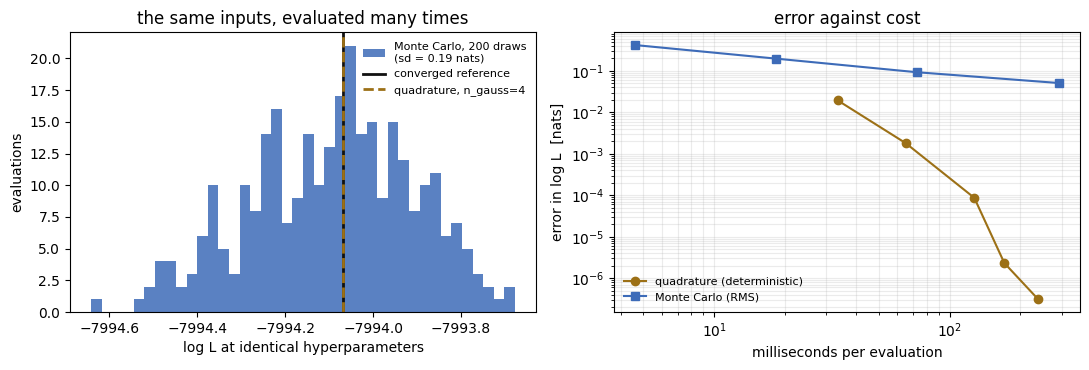

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))

ax1.hist(mc_values, bins=40, color="#3d6bb8", alpha=0.85,
         label=f"Monte Carlo, 200 draws\n(sd = {np.std(mc_values, ddof=1):.2f} nats)")
ax1.axvline(REFERENCE, color="#111111", lw=2, label="converged reference")
ax1.axvline(np.mean(quad_values), color="#9c7016", lw=2, ls="--",
            label="quadrature, n_gauss=4")
ax1.set_xlabel("log L at identical hyperparameters")
ax1.set_ylabel("evaluations")
ax1.set_title("the same inputs, evaluated many times")
ax1.legend(fontsize=8, frameon=False)

quad_rows = [r for r in rows if r[0] == "quadrature"]
mc_rows = [r for r in rows if r[0] == "monte carlo"]
ax2.loglog([1e3 * r[5] for r in quad_rows], [r[4] for r in quad_rows],
           "o-", color="#9c7016", label="quadrature (deterministic)")
ax2.loglog([1e3 * r[5] for r in mc_rows], [r[4] for r in mc_rows],
           "s-", color="#3d6bb8", label="Monte Carlo (RMS)")
ax2.set_xlabel("milliseconds per evaluation")
ax2.set_ylabel("error in log L  [nats]")
ax2.set_title("error against cost")
ax2.grid(alpha=0.25, which="both")
ax2.legend(fontsize=8, frameon=False)

fig.tight_layout()
plt.show()

## 5. What it would take Monte Carlo to match

The Monte Carlo error falls as `1/sqrt(N)`, so matching a given quadrature accuracy needs a
number of draws that grows as the inverse square of the target. For the sharper settings
this stops being a question of patience.

In [15]:
mc_200 = [r for r in rows if r[1] == "200 draws"][0]
rmse_200, time_200 = mc_200[4], mc_200[5]

print(f"Monte Carlo error ~ {rmse_200:.3f} / sqrt(N / 200) nats\n")
print(f"{'quadrature setting':<20} {'error':>10} {'ms':>8} {'MC draws to match':>20} {'MC time':>12}")
print("-" * 76)
for method, setting, nodes, value, err, dt in rows:
    if method != "quadrature" or err <= 0:
        continue
    n_needed = 200 * (rmse_200 / err) ** 2
    seconds = n_needed / 200 * time_200
    human = f"{seconds:,.1f} s" if seconds < 3600 else f"{seconds/3600:,.1f} h"
    print(f"{setting:<20} {err:>10.1e} {1e3*dt:>8.1f} {n_needed:>20,.0f} {human:>12}")

Monte Carlo error ~ 0.198 / sqrt(N / 200) nats

quadrature setting        error       ms    MC draws to match      MC time
----------------------------------------------------------------------------
n_gauss=2               2.0e-02     33.4               20,539        1.9 s
n_gauss=3               1.8e-03     65.1            2,390,560      219.1 s
n_gauss=4               8.7e-05    127.5        1,048,030,069       26.7 h
n_gauss=5               2.3e-06    171.0    1,473,342,461,793   37,512.6 h
n_gauss=6               3.1e-07    238.3   83,698,442,182,566 2,131,036.2 h


## 6. When it does not apply

The quadrature exploits specific structure — that `lambda_mst` and `kappa_ext` enter only
through their product, that the kinematics covariance is affine in `Ds/Dds`, and that the
latent parameters are at most a scalar anisotropy plus a scalar axis ratio. Configurations
outside that raise `QuadratureNotApplicable` rather than quietly returning a number
computed under assumptions that do not hold.

Use `marginalisation="quadrature_if_applicable"` to apply it where it fits and fall back to
the Monte Carlo loop elsewhere, which is the sensible choice for a mixed lens sample.

In [16]:
from hierarc.Likelihood.quadrature_marginalisation import QuadratureNotApplicable

unsupported = dict(kwargs_lens_setup)
unsupported["anisotropy_model"] = "OM"   # a two-parameter anisotropy model

try:
    LensLikelihood(marginalisation="quadrature", **unsupported)
except QuadratureNotApplicable as error:
    print("refused, as it should be:\n ", error)

with warnings.catch_warnings():
    warnings.simplefilter("always")
    lens = LensLikelihood(marginalisation="quadrature_if_applicable", **unsupported)
print("\nfallback: quadrature is", "off" if lens._quadrature is None else "on",
      "-> this lens uses the Monte Carlo loop")
print("log L =", evaluate(lens))

refused, as it should be:
  lens DEMO: anisotropy model 'OM' is not supported (only 'const' has a scalar latent parameter). Use the Monte Carlo marginalisation for this lens.

fallback: quadrature is off -> this lens uses the Monte Carlo loop
log L = -7994.044606364501


/Users/martin/Desktop/modules/hierArc/hierarc/Likelihood/hierarchy_likelihood.py:272: UserWarning: quadrature marginalisation does not apply to lens DEMO; falling back to the Monte Carlo loop for it.
  warnings.warn(


## Summary

- The quadrature is **optional and off by default**; `marginalisation="mc"` is unchanged.
- Where it applies it is deterministic and converges geometrically, so its error can be
  verified by refining `n_gauss` — something the Monte Carlo error cannot be.
- Its cost is a modest constant factor per evaluation. The gain is not raw speed but the
  removal of the log-likelihood noise that degrades emcee's mixing.
- The lenses that benefit most are exactly the ones with the most kinematic information,
  where the Monte Carlo estimator is worst. Raise `N_BINS` at the top and re-run to see
  the gap widen.